# ARTwarp-py — Demo & Guide

A complete, runnable introduction to **ARTwarp-py**: load real contour files, train the network, interpret every result, and produce publication-quality* figures.

**What this notebook covers**

| Section | Topic |
|---------|-------|
| 1 | Imports & setup |
| 2 | Load real contours from `examples/data/` |
| 3 | Data exploration — length & temporal resolution |
| 4 | (Optional) Resampling to a common temporal resolution |
| 5 | Train the ARTwarp network |
| 6 | Inspect training results |
| 7 | Standard result visualizations |
| 8 | Algorithm diagrams |
| 9 | Diagnostic visualizations |
| 10 | Data-quality visualizations |
| 11 | Parameter-study visualizations |
| 12 | Publication figure |
| 13 | Ground-truth evaluation (confusion matrix, label map) |
| 14 | Full automated report |
| 15 | Predict on new contours |
| 16 | Export results |
| 17 | CLI quick reference |

> **Docs:** `docs/user/API.md` · `docs/user/QUICK_REFERENCE.md` · `docs/user/VISUALIZATION.md`

*Always double check figure for DPI, dimension, etc, before publication.

@author: Pedro Gronda Garrigues

---
## 1  ·  Imports & setup

Install the package once from the project root: `pip install -e .`  
All cells below require only `artwarp`, `numpy`, and `matplotlib`.

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110

from pathlib import Path

# core API
from artwarp import ARTwarp, load_contours
from artwarp.utils import resample_contours
from artwarp.io.exporters import (
    export_results,
    export_reference_contours,
    export_category_assignments,
)

# all visualization functions
from artwarp.visualization import (
    create_paper_figure,
    create_results_report,
    plot_art_schematic,
    plot_category_distribution,
    plot_category_embedding,
    plot_category_similarity_matrix,
    plot_category_dendrogram,
    plot_confusion_matrix,
    plot_contour_length_distribution,
    plot_contours_by_category,
    plot_convergence_history,
    plot_discovery_curve,
    plot_dtw_alignment,
    plot_label_vs_category,
    plot_match_distribution,
    plot_per_category_match_quality,
    plot_reference_contours,
    plot_resampling_before_after,
    plot_run_stability,
    plot_training_summary,
    plot_vigilance_sweep,
    plot_warp_constraint,
)

import artwarp
print(f"artwarp-py  version: {artwarp.__version__}")
print(f"numpy       version: {np.__version__}")

artwarp-py  version: 2.0.3
numpy       version: 2.3.5


---
## 2  ·  Load real contours from `examples/data/`

The `data/` directory contains five dolphin-whistle contour CSV files (columns: `Time [ms]`, `Peak Frequency [Hz]`). These were kindly provided by @Kai Kerlaff, and are in the latest release of ARTwarp (MATLAB version).
 
`load_contours` auto-detects the frequency and time columns.  
Passing `return_tempres=True` also returns the per-file temporal resolution inferred from the time column.

In [44]:
DATA_DIR = Path("data")   # relative to examples/

contours, names, tempres_list = load_contours(
    str(DATA_DIR),
    file_format="csv",
    return_tempres=True,
)

print(f"Loaded {len(contours)} contours")
for name, ctr, tr in zip(names, contours, tempres_list):
    print(f"  {name:20s}  length={len(ctr):4d} pts   tempres={tr:.4f} s/pt   "
          f"duration={len(ctr)*tr*1000:.1f} ms   "
          f"freq=[{ctr.min():.0f}, {ctr.max():.0f}] Hz")

Loaded 5 contours
  CSV001                length= 231 pts   tempres=0.0050 s/pt   duration=1155.0 ms   freq=[10500, 14000] Hz
  CSV002                length= 242 pts   tempres=0.0050 s/pt   duration=1210.0 ms   freq=[11625, 15500] Hz
  CSV003                length= 284 pts   tempres=0.0050 s/pt   duration=1420.0 ms   freq=[12750, 17000] Hz
  CSV004                length= 211 pts   tempres=0.0050 s/pt   duration=1055.0 ms   freq=[13875, 18500] Hz
  CSV005                length= 213 pts   tempres=0.0050 s/pt   duration=1065.0 ms   freq=[15000, 20000] Hz


---
## 3  ·  Data exploration — length & temporal resolution

Before training it is good practice to understand your dataset's shape.  
`plot_contour_length_distribution` gives you histograms of both contour length (in samples) and temporal resolution (seconds per sample) in one figure.  
Contours with very different temporal resolutions should be resampled to a common interval before training (see Section 4).

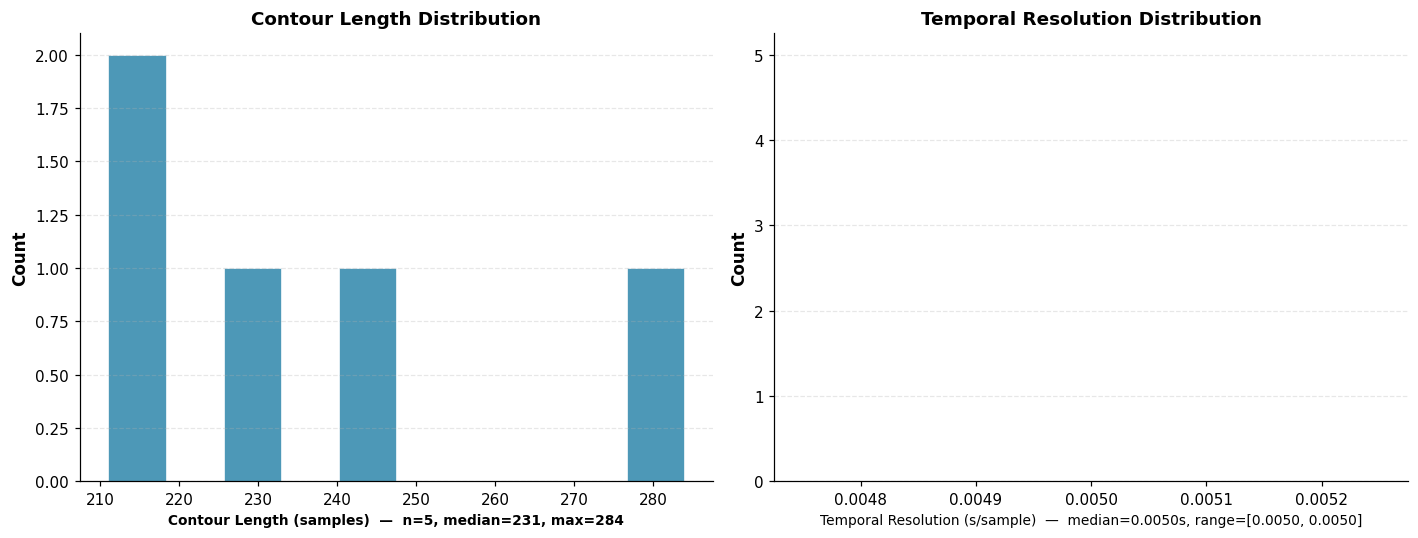

In [3]:
fig = plot_contour_length_distribution(
    contours,
    tempres_list=tempres_list,
    figsize=(13, 5),
)
plt.show()

---
## 4  ·  (Optional) Resampling to a common temporal resolution

If your files have different temporal resolutions (e.g., 5 ms vs 10 ms per sample), DTW comparisons can be misleading because one contour appears longer than it physically is.  
Resampling interpolates every contour to the same time step.

`plot_resampling_before_after` shows the effect on a single contour so you can sanity-check the result.

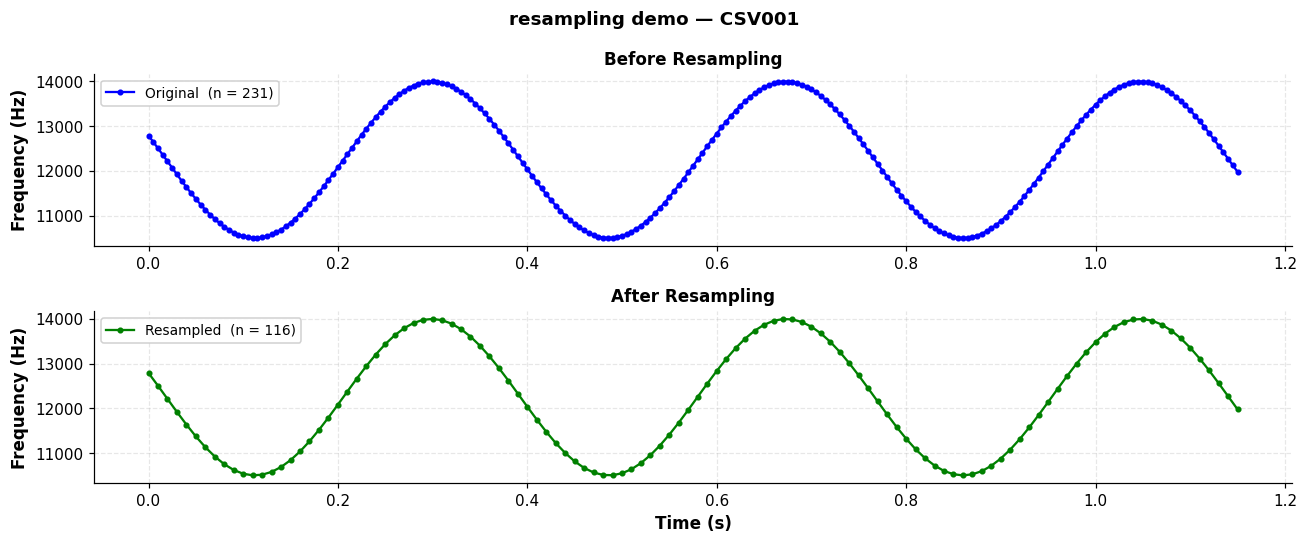

In [34]:
SAMPLE_INTERVAL = 0.005  # 5 ms per sample — keeps original resolution for this dataset

# visualise what resampling to 10 ms would look like on the first contour
fig = plot_resampling_before_after(
    contours[0],
    tempres=tempres_list[0],
    sample_interval_sec=0.010,
    title=f"resampling demo — {names[0]}",
    figsize=(12, 5),
)
plt.show()

In [35]:
# apply resampling (here we resample to 5 ms to normalise any small differences)
contours_resampled = resample_contours(contours, tempres_list, SAMPLE_INTERVAL)

print("Contour lengths before and after resampling:")
for name, orig, resampled in zip(names, contours, contours_resampled):
    print(f"  {name:20s}  {len(orig):4d} → {len(resampled):4d} pts")

# use resampled contours for training
train_contours = contours_resampled

Contour lengths before and after resampling:
  CSV001                 231 →  231 pts
  CSV002                 242 →  242 pts
  CSV003                 284 →  284 pts
  CSV004                 211 →  211 pts
  CSV005                 213 →  213 pts


---
## 5  ·  Train the ARTwarp network

Key parameters:

| Parameter | Meaning |
|-----------|--------|
| `vigilance` (ρ) | Match threshold 0–100 %. Higher → more, finer categories. |
| `learning_rate` | How fast prototypes update toward new members (0–1). |
| `bias` | Slightly deflates activation for new categories, favouring existing ones. |
| `warp_factor_level` | Maximum local time-compression/expansion allowed in DTW. |
| `max_iterations` | Upper bound on training passes over the dataset. |

In [6]:
network = ARTwarp(
    vigilance=95.0,
    learning_rate=0.1,
    bias=0.000001,
    max_categories=5,
    max_iterations=50,
    warp_factor_level=3,
    random_seed=42,
    verbose=True,
)

results = network.fit(train_contours, contour_names=names)

ARTwarp Training
Samples:         5
Max contour len: 284
Vigilance:       95.0
Learning rate:   0.1
Bias:            1e-06
Max categories:  5
Max iterations:  50
Warp factor:     3
Random seed:     42

  iter   1  │  categories   2  (+ 2 this round)  │  reclassified    5 / 5 (100.0%)
  iter   2  │  categories   2  (+ 0 this round)  │  reclassified    0 / 5 (  0.0%)

Converged after 2 iterations

Training completed in 0.13 seconds
Final categories: 2
Uncategorized: 0


---
## 6  ·  Inspect training results

The `TrainingResults` object returned by `fit()` holds everything you need for post-hoc analysis.

In [7]:
print(f"Categories formed  : {results.num_categories}")
print(f"Training iterations: {results.num_iterations}")
print(f"Converged          : {results.converged}")
print(f"Training time      : {results.training_time:.3f} s")
print(f"Uncategorized      : {results.get_uncategorized_count()}")
print()

sizes = results.get_category_sizes()
print("Category sizes:")
for cat_id, count in sorted(sizes.items()):
    mask = results.categories == cat_id
    cat_matches = results.matches[mask]
    cat_matches = cat_matches[np.isfinite(cat_matches)]
    mean_m = np.mean(cat_matches) if len(cat_matches) else float('nan')
    members = [names[i] for i in range(len(names)) if results.categories[i] == cat_id]
    print(f"  Category {cat_id}: {count:3d} contour(s)   mean match = {mean_m:.1f}%   {members}")

Categories formed  : 2
Training iterations: 2
Converged          : True
Training time      : 0.125 s
Uncategorized      : 0

Category sizes:
  Category 0:   3 contour(s)   mean match = 97.0%   ['CSV001', 'CSV002', 'CSV003']
  Category 1:   2 contour(s)   mean match = 98.1%   ['CSV004', 'CSV005']


---
## 7  ·  Standard result visualizations

### 7a  Training summary (multi-panel overview)

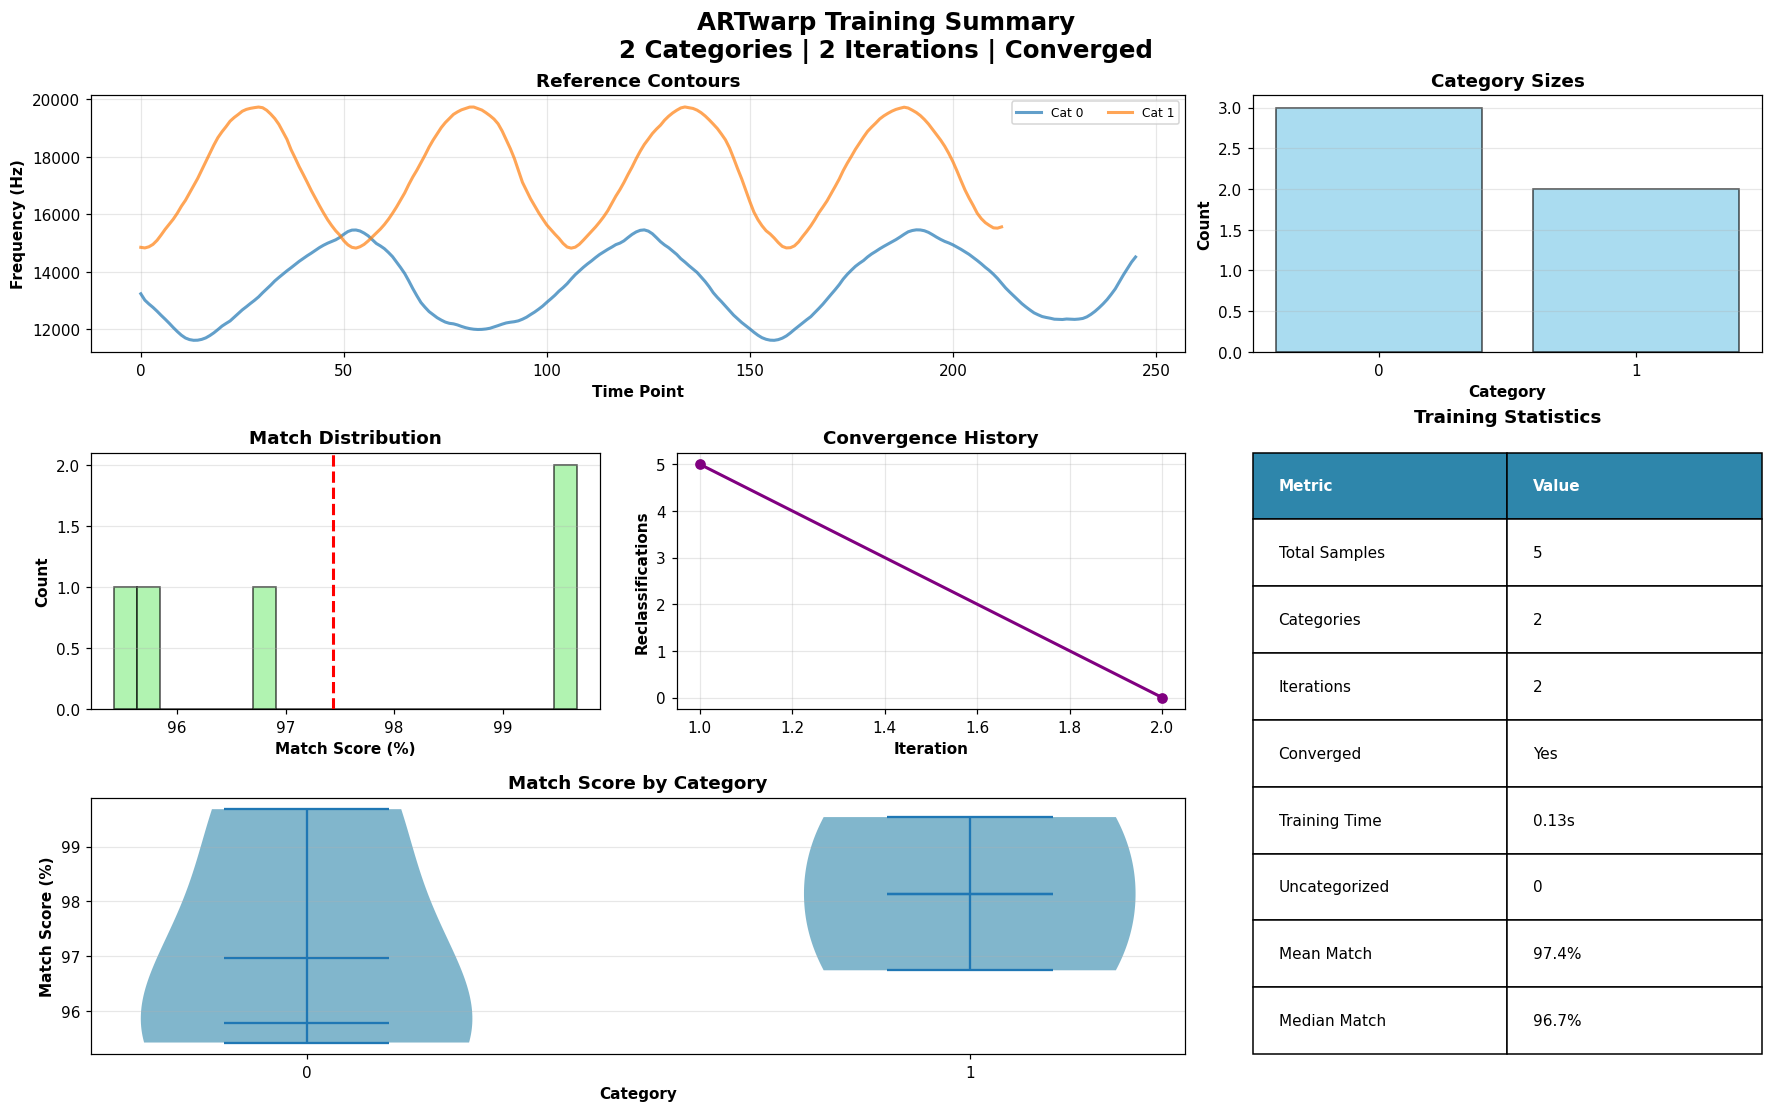

In [8]:
fig = plot_training_summary(results, contour_names=names, figsize=(16, 10))
plt.show()

### 7b  Reference contours (category prototypes)

Each panel shows the learned prototype contour for one category.

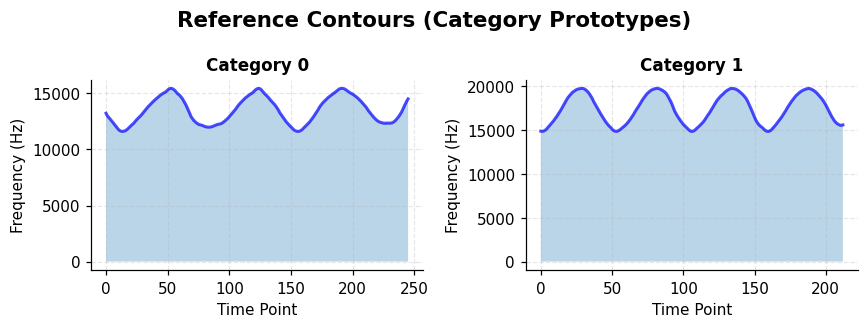

In [9]:
fig = plot_reference_contours(results.weight_matrix)
plt.show()

### 7c  Category distribution

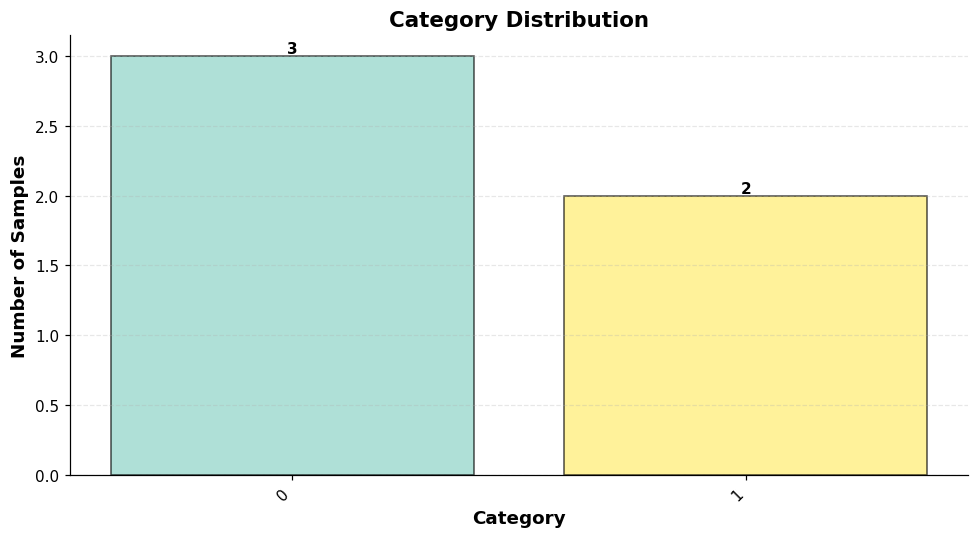

In [10]:
fig = plot_category_distribution(results, figsize=(9, 5))
plt.show()

### 7d  Convergence history

Shows reclassifications per iteration. The curve reaching zero (or near zero) means the network has converged.

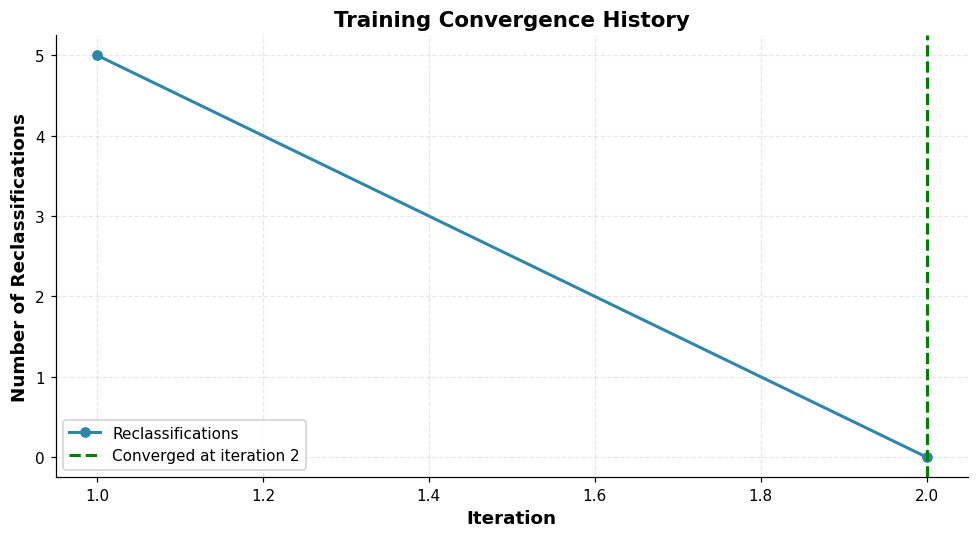

In [11]:
fig = plot_convergence_history(results, figsize=(9, 5))
plt.show()

### 7e  Match score distribution

Histogram of how well each contour matched its assigned prototype.  
A distribution clustered near 100 % means tight, well-separated categories.

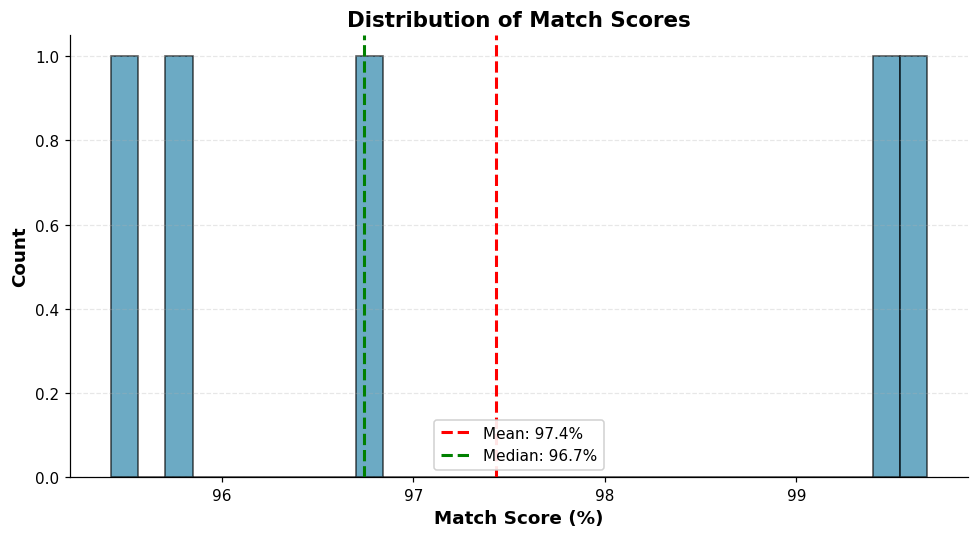

In [12]:
fig = plot_match_distribution(results, figsize=(9, 5))
plt.show()

### 7f  Category discovery curve

The curve rises each time a new category is first created and stays flat when a sample joins an existing one.  
A plateau indicates the dataset has revealed its full repertoire.  
This is the Python equivalent of the MATLAB `DiscoveryCurves.m` utility.

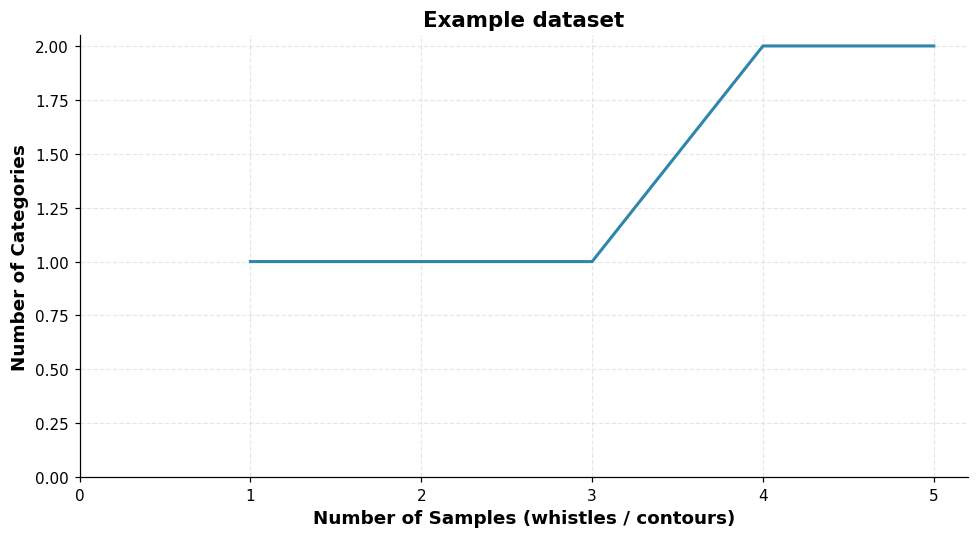

In [13]:
fig = plot_discovery_curve(results, title="Example dataset", figsize=(9, 5))
plt.show()

### 7g  Contours in a specific category

Overlays all contours assigned to one category with the reference prototype in red.

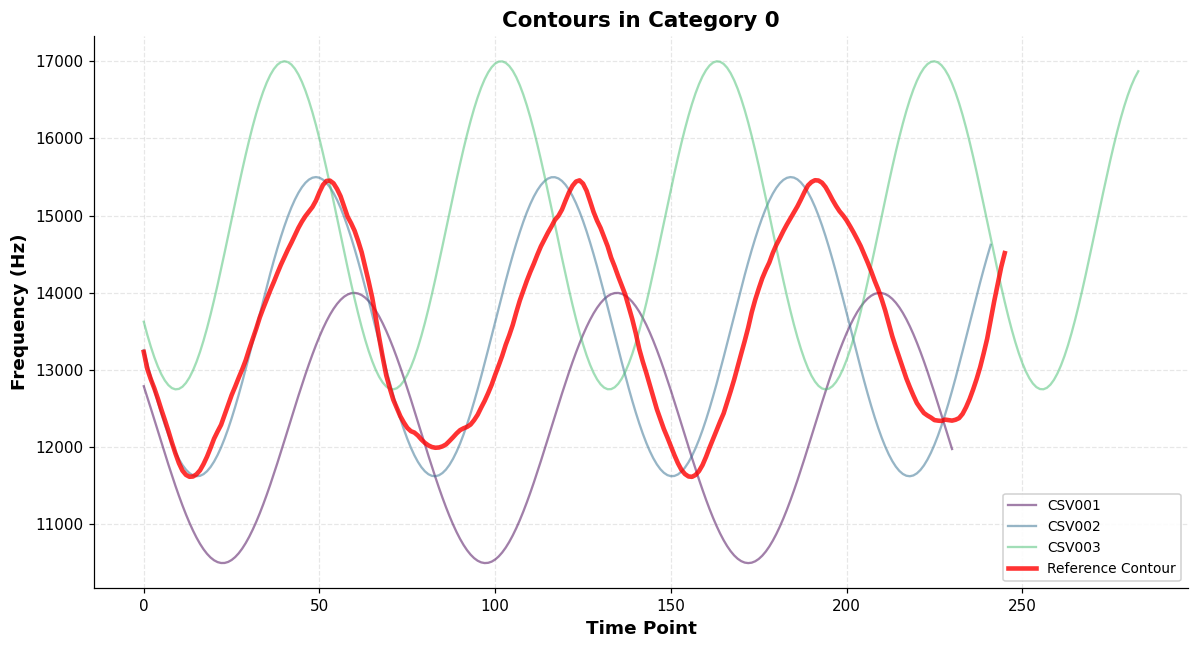

In [14]:
first_cat = sorted(results.get_category_sizes())[0]
ref = results.weight_matrix[:, first_cat]
ref_clean = ref[~np.isnan(ref)]

fig = plot_contours_by_category(
    train_contours, results.categories,
    category_id=first_cat,
    contour_names=names,
    reference_contour=ref_clean,
    figsize=(11, 6),
)
plt.show()

---
## 8  ·  Algorithm diagrams

These figures explain **how** ARTwarp works. They are useful for method sections of papers or presentations.

### 8a  ARTwarp decision flow

Shows the four-step per-sample decision loop: input → DTW to all prototypes → sort by activation → vigilance test → commit or new category.

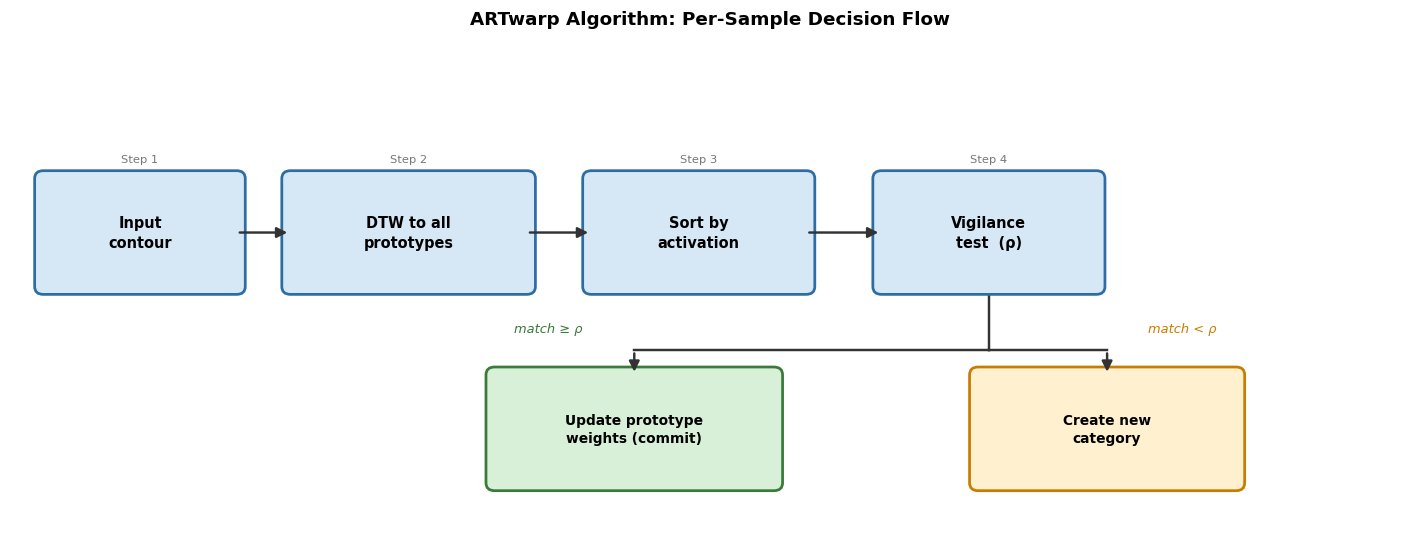

In [15]:
fig = plot_art_schematic(figsize=(13, 5))
plt.show()

### 8b  Itakura warping constraint

The shaded region shows which cells in the alignment grid a DTW path is allowed to visit for `warp_factor_level = 3`.  
Cells outside the band are pruned — they represent implausible time-compressions or expansions.

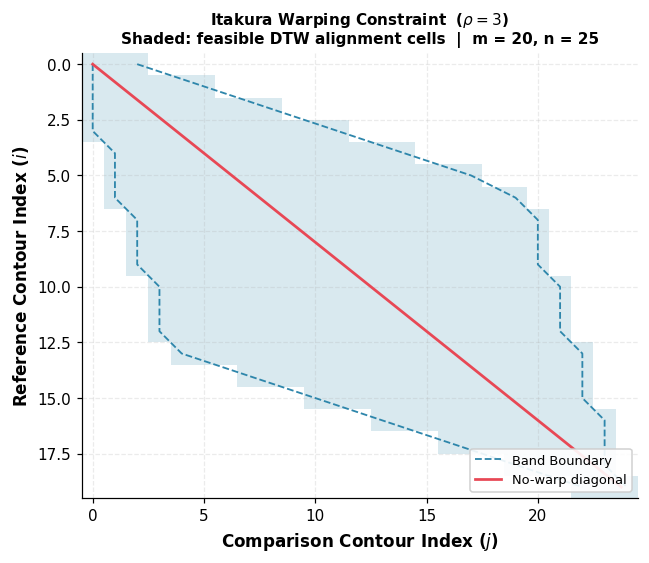

In [16]:
fig = plot_warp_constraint(warp_factor_level=3, m=20, n=25, figsize=(6, 6))
plt.show()

### 8c  DTW alignment path

Left: the two contours overlaid. Right: the optimal warping path through the alignment grid (shaded = Itakura band; dotted = no-warp diagonal).  
A path hugging the diagonal means the two contours are very similar in timing.

Showing alignment for contour 'CSV001' vs its category 0 prototype


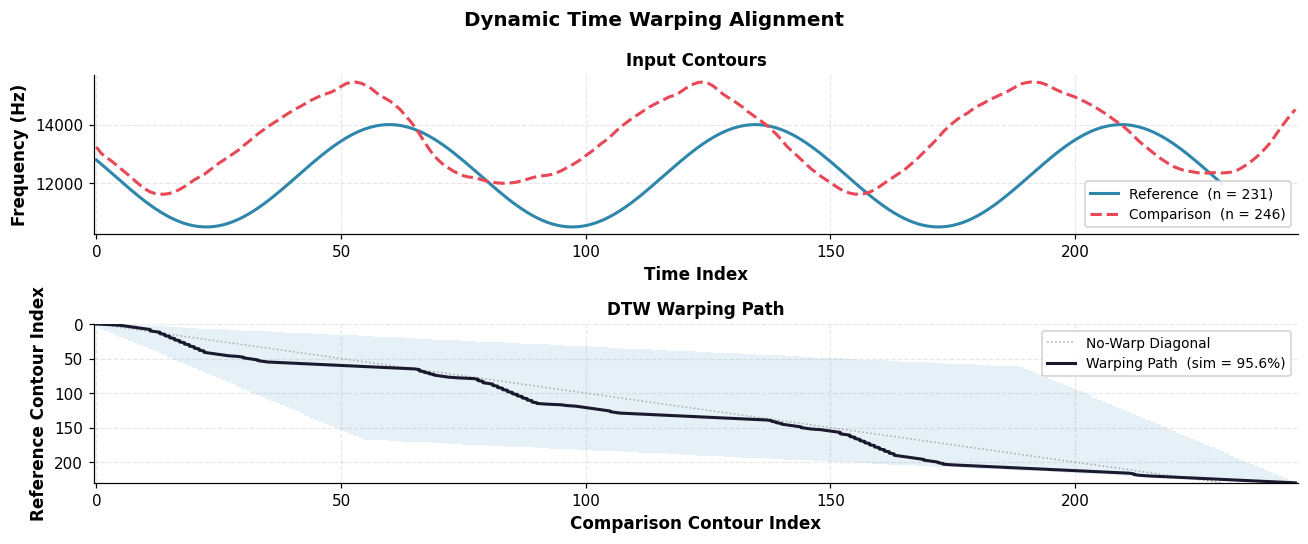

In [17]:
from artwarp.core.dtw import dynamic_time_warp

wfl = 3
dtw_fig = None
for ci, ctr in enumerate(train_contours):
    cat = int(results.categories[ci])
    if cat >= results.weight_matrix.shape[1]:
        continue
    ref_col = results.weight_matrix[:, cat]
    ref_col = ref_col[~np.isnan(ref_col)]
    if len(ref_col) == 0:
        continue
    ratio = max(len(ctr), len(ref_col)) / max(1, min(len(ctr), len(ref_col)))
    if ratio < wfl:
        dtw_fig = plot_dtw_alignment(
            ctr, ref_col.astype(np.float64),
            warp_factor_level=wfl, figsize=(12, 5),
        )
        print(f"Showing alignment for contour '{names[ci]}' vs its category {cat} prototype")
        break

if dtw_fig:
    plt.show()
else:
    print("No compatible pair found — try a higher warp_factor_level")

---
## 9  ·  Diagnostic visualizations

These figures help you assess the **quality** of the learned categories.

### 9a  Per-category match quality

Violin plot of match scores within each category.  
Narrow violins near 100 % indicate tight, cohesive categories.  
Wide or low-scoring violins may suggest that the category has mixed-type members.

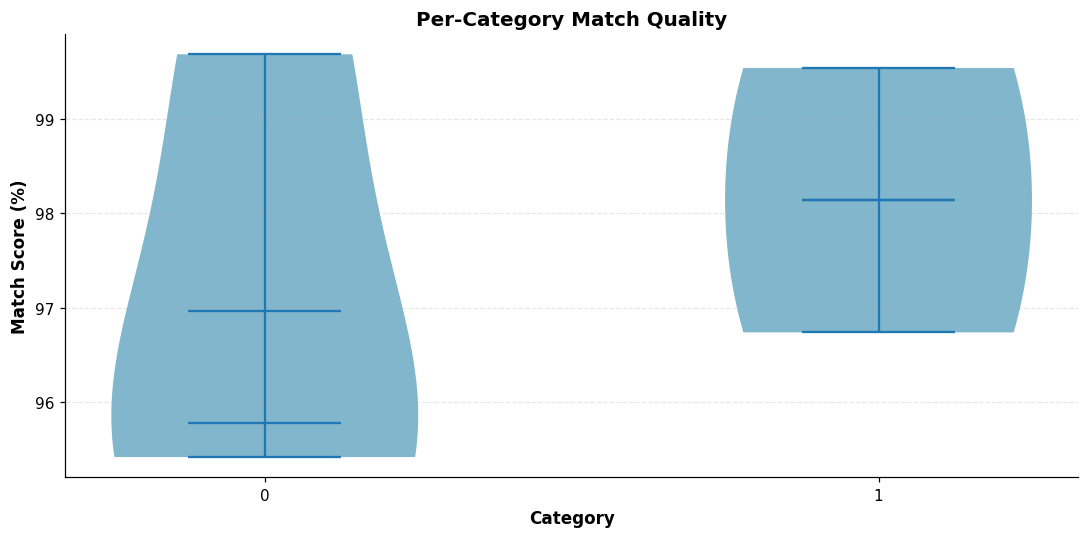

In [18]:
fig = plot_per_category_match_quality(results, figsize=(10, 5))
plt.show()

### 9b  Pairwise DTW similarity matrix

Each cell shows the DTW similarity (%) between two category prototypes.  
The diagonal is always 100 % (a prototype compared to itself).  
High off-diagonal values reveal categories that are acoustically close and could potentially be merged.

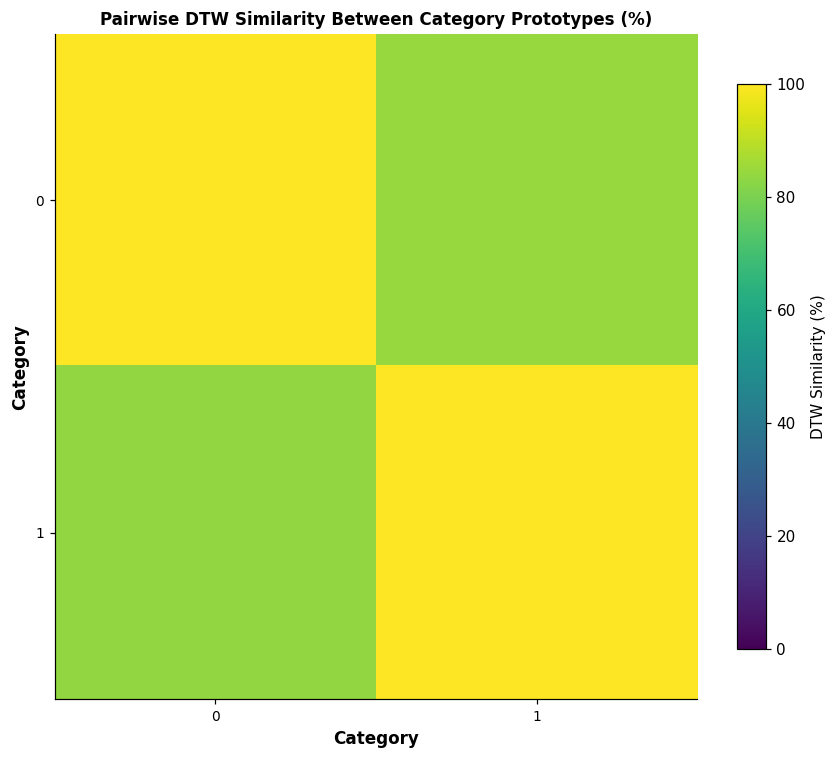

In [19]:
fig = plot_category_similarity_matrix(
    results.weight_matrix, warp_factor_level=3, figsize=(8, 7)
)
plt.show()

### 9c  Acoustic space embedding (MDS)

Pairwise DTW distances between all prototypes are reduced to 2D via classical Multidimensional Scaling.  
Points close together are acoustically similar; distant points are perceptually distinct call types.  
Dimension 1 captures the most variation; Dimension 2 the next most.

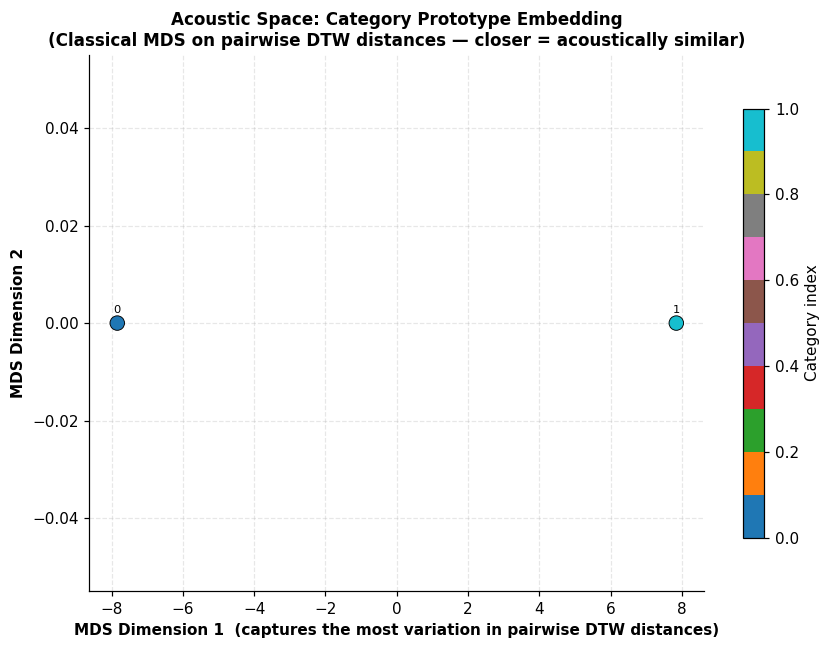

In [20]:
fig = plot_category_embedding(
    results.weight_matrix, warp_factor_level=3, figsize=(8, 6)
)
plt.show()

### 9d  Category dendrogram  *(requires scipy)*

Hierarchical clustering of prototypes by DTW distance (average linkage).  
Categories that merge at low height are acoustically similar.

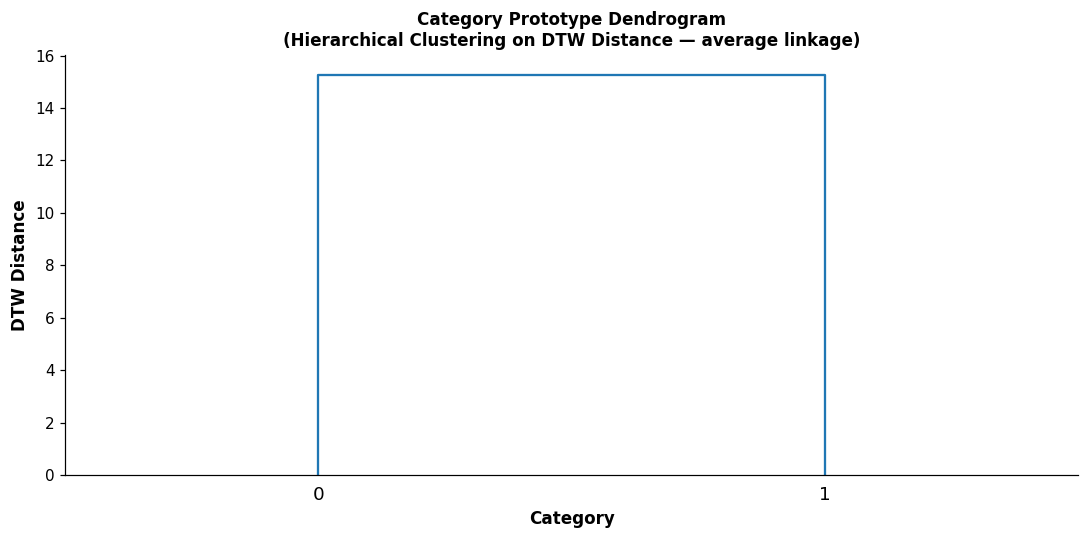

In [21]:
try:
    fig = plot_category_dendrogram(
        results.weight_matrix, warp_factor_level=3, figsize=(10, 5)
    )
    plt.show()
except ImportError:
    print("scipy is not installed — install with: pip install scipy")

---
## 10  ·  Data-quality visualizations

### 10a  Contour length & temporal resolution distributions

Already shown in Section 3. Here we confirm the resampled dataset looks as expected.

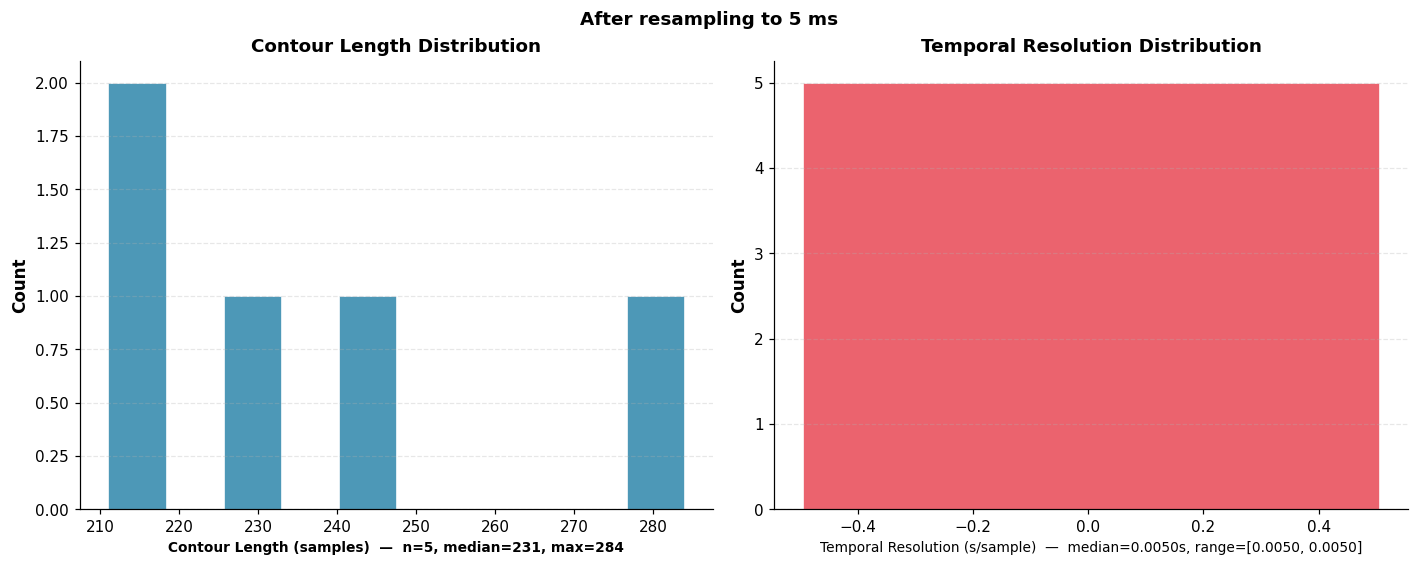

In [22]:
resampled_tempres = [SAMPLE_INTERVAL] * len(train_contours)
fig = plot_contour_length_distribution(
    train_contours,
    tempres_list=resampled_tempres,
    figsize=(13, 5),
)
plt.suptitle("After resampling to 5 ms", fontsize=12, fontweight="bold", y=1.02)
plt.show()

---
## 11  ·  Parameter-study visualizations

### 11a  Vigilance sweep

Train the same dataset across a range of vigilance values and plot the resulting number of categories (left axis, blue) and mean match score (right axis, red).  
Use this to pick a vigilance that balances granularity vs. cohesion.

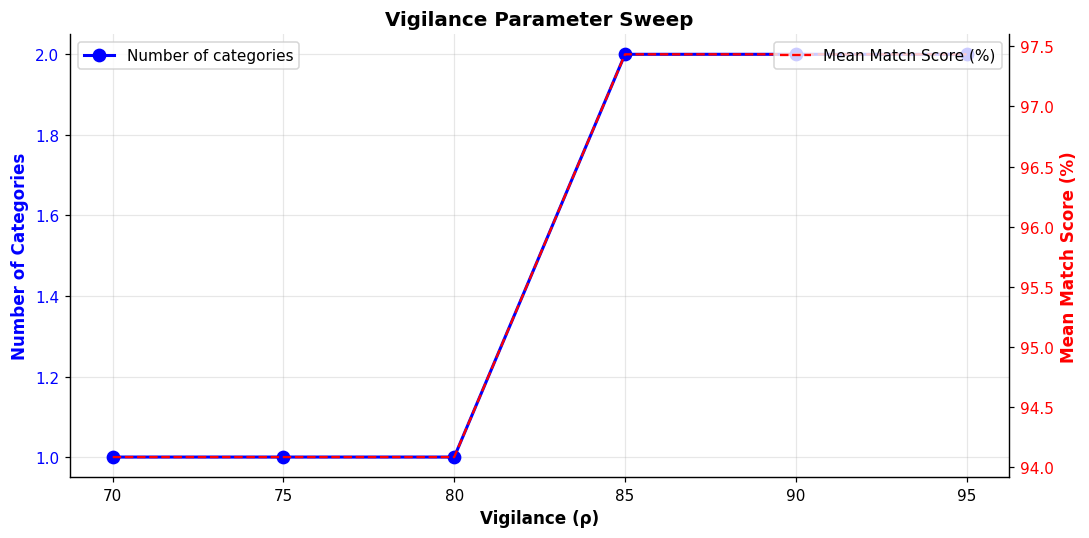

In [23]:
vigilance_values = [70.0, 75.0, 80.0, 85.0, 90.0, 95.0]

sweep_results = [
    (
        v,
        ARTwarp(vigilance=v, random_seed=42, verbose=False).fit(train_contours),
    )
    for v in vigilance_values
]

fig = plot_vigilance_sweep(sweep_results, figsize=(10, 5))
plt.show()

### 11b  Run stability

Trains the network with the same settings but different random seeds (which shuffle presentation order).  
A tight distribution means the algorithm is stable regardless of order; a wide spread suggests order sensitivity.

Categories per seed: [1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 1, 2]


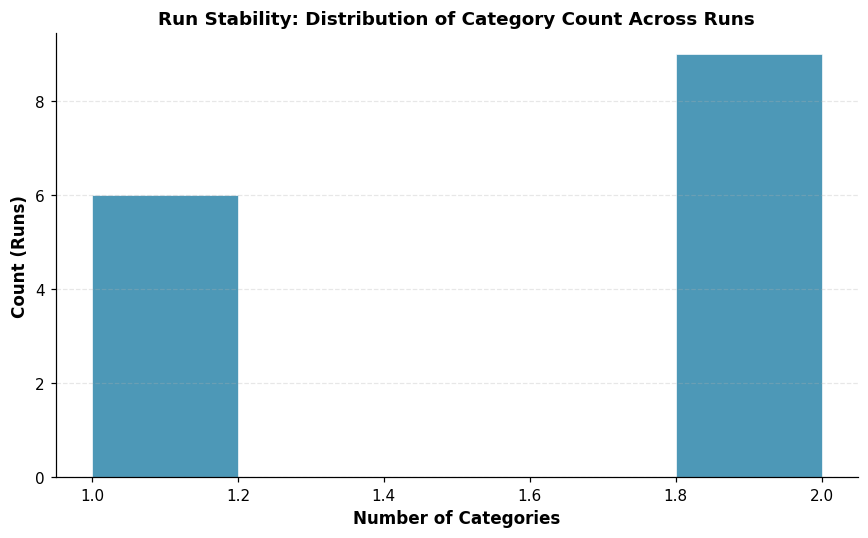

In [24]:
n_cats_per_seed = [
    ARTwarp(vigilance=85.0, random_seed=s, verbose=False)
    .fit(train_contours)
    .num_categories
    for s in range(15)
]

print("Categories per seed:", n_cats_per_seed)
fig = plot_run_stability(n_cats_per_seed, figsize=(8, 5))
plt.show()

---
## 12  ·  Publication figure

`create_paper_figure` combines reference contours, discovery curve, and category distribution into a single multi-panel figure ready for a methods section.

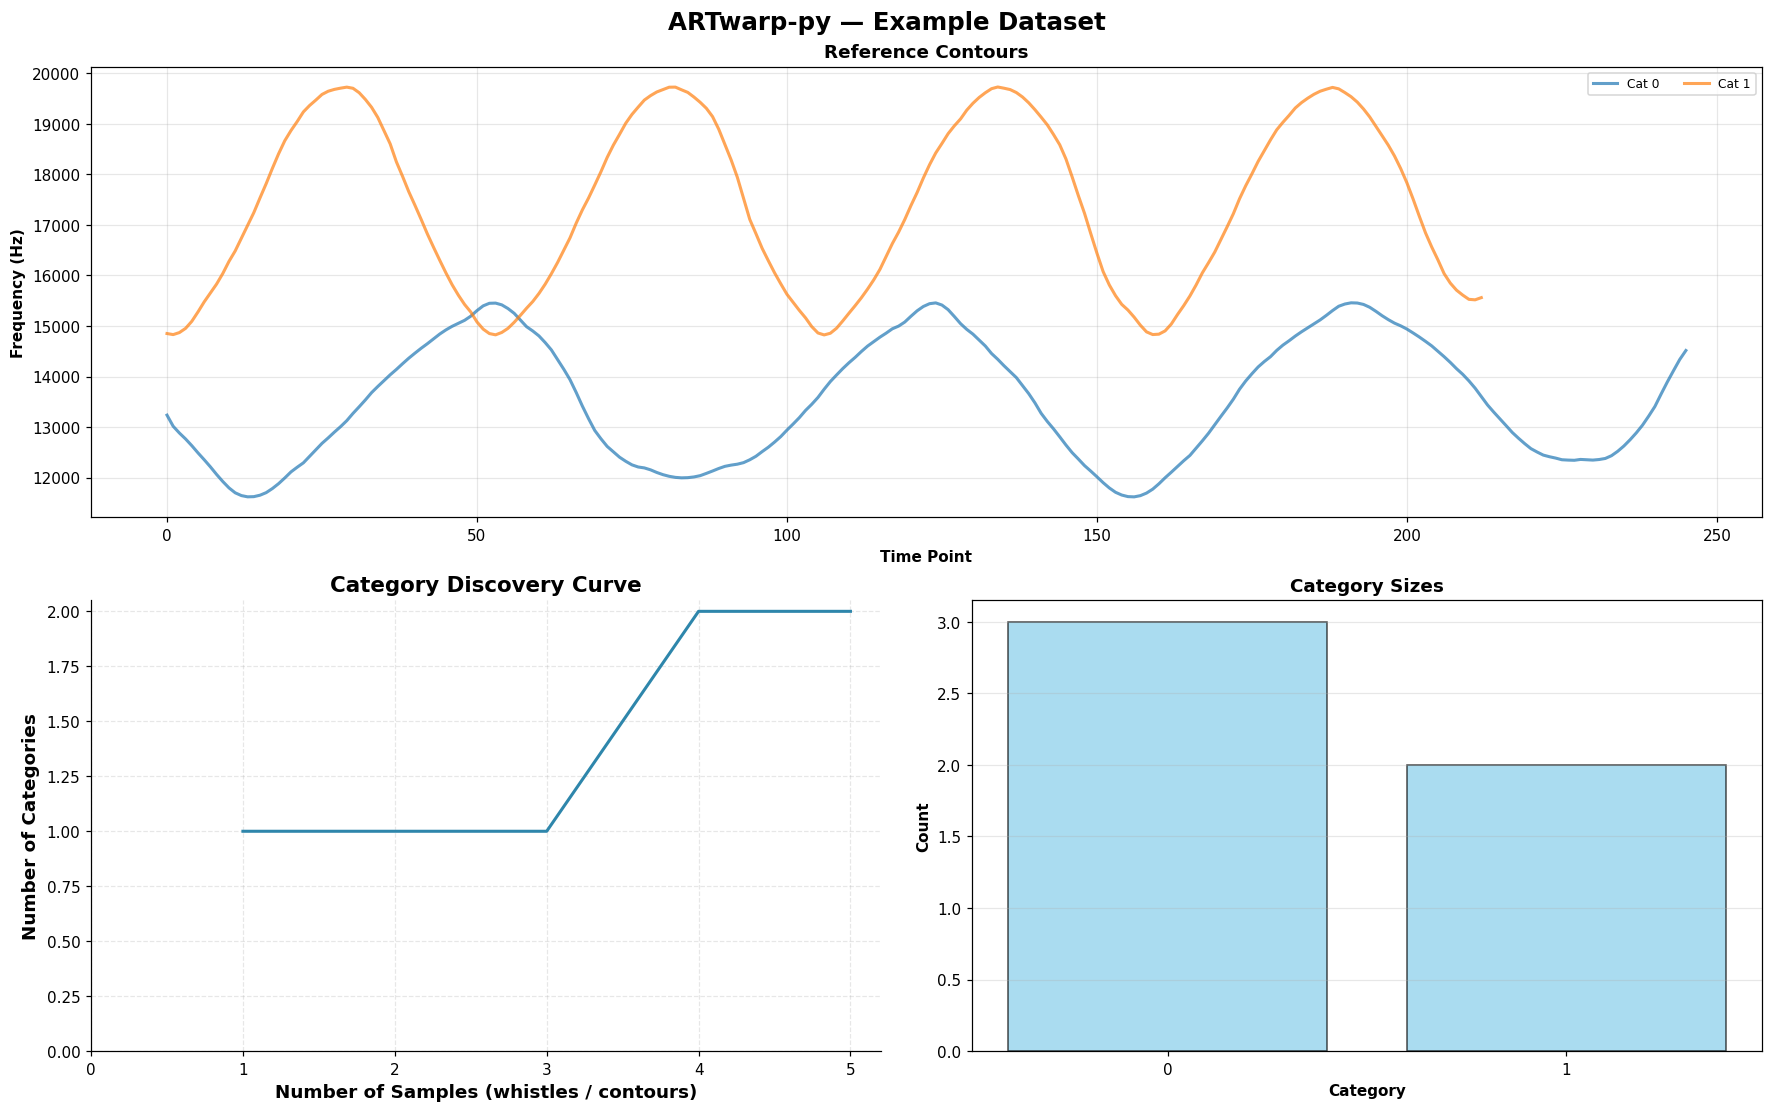

In [25]:
fig = create_paper_figure(
    results,
    train_contours,
    contour_names=names,
    title="ARTwarp-py — Example Dataset",
    figsize=(16, 10),
)
plt.show()

---
## 13  ·  Ground-truth evaluation

If you have external labels for your recordings (e.g., manually identified whistle types), you can compare them to the categories ARTwarp discovered.

Here we construct **synthetic labels** to show how these plots work.  
In a real project you would load labels from a CSV or annotation file and align them to `names`.

### How to provide labels in practice

```python
# Option 1: load from a CSV that has (filename, label) columns
import pandas as pd
label_df = pd.read_csv("labels.csv", index_col="filename")
labels = [label_df.loc[n, "label"] for n in names]

# Option 2: build a dict manually
label_map = {"CSV001": "type_A", "CSV002": "type_B", ...}
labels = [label_map[Path(n).stem] for n in names]
```

In [26]:
# Synthetic ground-truth labels for demonstration
# (In a real project these would come from your annotation file)
rng = np.random.default_rng(0)
possible_labels = ["type_A", "type_B", "type_C"]
synthetic_labels = rng.choice(possible_labels, size=len(names))

# Encode strings as integers (required by the plotting functions)
unique_labels = sorted(set(synthetic_labels))
label_ids = np.array([unique_labels.index(l) for l in synthetic_labels], dtype=int)

print("Ground-truth label counts:")
for lb in unique_labels:
    print(f"  {lb}: {np.sum(synthetic_labels == lb)}")

Ground-truth label counts:
  type_A: 2
  type_B: 2
  type_C: 1


### 13a  Confusion matrix

Rows = ground-truth label, columns = ARTwarp category.  
A perfect clustering would have each row dominated by a single column (and vice versa).

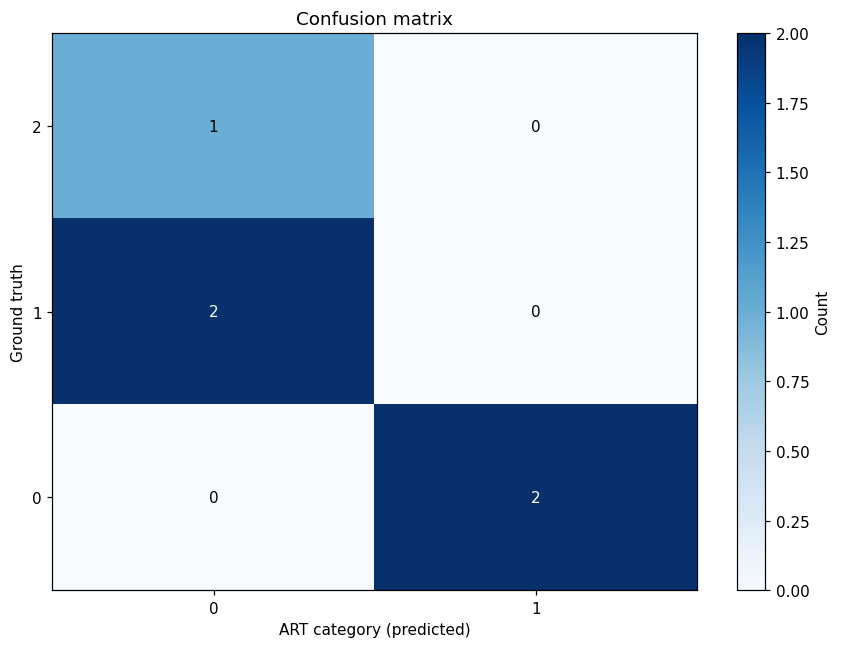

In [27]:
fig = plot_confusion_matrix(
    label_ids,
    results.categories,
    figsize=(8, 6),
)
plt.show()

### 13b  Label vs category distribution (stacked bar)

For each ARTwarp category (x-axis), a stacked bar shows the proportion of each ground-truth label.  
A pure category has only one color; a mixed category has several.  
Complements the confusion matrix with a proportional view.

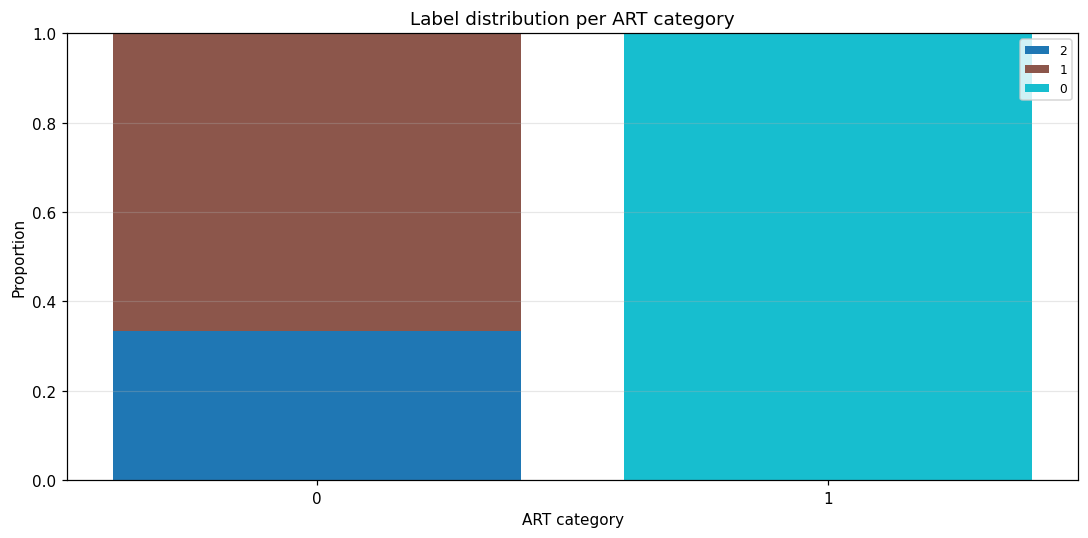

In [28]:
fig = plot_label_vs_category(
    label_ids,
    results.categories,
    figsize=(10, 5),
)
plt.show()

---
## 14  ·  Full automated report

`create_results_report` writes all standard and additional figures to a directory in one call.  
This is equivalent to running `artwarp-py plot` from the CLI.

In [29]:
REPORT_DIR = "./artwarp_demo_report"

report_files = create_results_report(
    results,
    train_contours,
    contour_names=names,
    output_dir=REPORT_DIR,
    dpi=150,
    include_additional=True,   # generates additional/ subdirectory
    warp_factor_level=3,
    tempres_list=resampled_tempres,
)

print(f"\nReport: {len(report_files)} figures saved to '{REPORT_DIR}/'")
print("\nMain directory figures:")
for k, v in sorted(report_files.items()):
    if not k.startswith("additional"):
        print(f"  {k}: {v}")
print("\nAdditional figures:")
for k, v in sorted(report_files.items()):
    if k.startswith("additional"):
        print(f"  {k}: {v}")

Creating training summary...
Creating reference contours plot...
Creating category distribution...
Creating convergence history...
Creating match distribution...
Creating discovery curve...
Creating per-category plots...
Creating additional figures in additional/...

Report: 18 figures saved to './artwarp_demo_report/'

Main directory figures:
  category_0: artwarp_demo_report/category_0_contours.png
  category_1: artwarp_demo_report/category_1_contours.png
  category_distribution: artwarp_demo_report/category_distribution.png
  convergence_history: artwarp_demo_report/convergence_history.png
  discovery_curve: artwarp_demo_report/discovery_curve.png
  match_distribution: artwarp_demo_report/match_distribution.png
  reference_contours: artwarp_demo_report/reference_contours.png
  training_summary: artwarp_demo_report/training_summary.png

Additional figures:
  additional/art_schematic: artwarp_demo_report/additional/art_schematic.png
  additional/category_dendrogram: artwarp_demo_repor

---
## 15  ·  Predict on new contours

After training you can classify new, unseen contours without re-training.  
Use `network.predict()` — it returns category IDs and match scores.

In [30]:
# Treat the original (pre-resampled) contours as "new" data
new_contours = contours_resampled[:3]
new_names    = names[:3]

pred_categories, pred_matches = network.predict(new_contours)

print("Predictions on new contours:")
for name, cat, match in zip(new_names, pred_categories, pred_matches):
    print(f"  {name:20s}  →  category {int(cat):2d}   match = {match:.1f}%")

Predictions on new contours:
  CSV001                →  category  0   match = 96.0%
  CSV002                →  category  0   match = 99.6%
  CSV003                →  category  0   match = 96.0%


---
## 16  ·  Export results

Three export functions cover the typical post-training workflow:

| Function | Output |
|----------|--------|
| `export_results` | Pickled `TrainingResults` (`.pkl`) for later loading |
| `export_reference_contours` | CSV with one row per category prototype |
| `export_category_assignments` | CSV with one row per input contour (name, category, match) |

In [31]:
import os
os.makedirs("artwarp_demo_output", exist_ok=True)

# 1. Save full results (reload with artwarp.io.load_results)
export_results(results, "artwarp_demo_output/results.pkl")

# 2. Export reference contours (one column per category)
export_reference_contours(results, "artwarp_demo_output/reference_contours.csv")

# 3. Export per-contour assignments
export_category_assignments(
    results, names, "artwarp_demo_output/assignments.csv"
)

print("Saved:")
for f in sorted(os.listdir("artwarp_demo_output")):
    size = os.path.getsize(f"artwarp_demo_output/{f}")
    print(f"  artwarp_demo_output/{f}  ({size:,} bytes)")

AttributeError: 'TrainingResults' object has no attribute 'shape'

In [ ]:
# Reload saved results
from artwarp.io import load_results
from artwarp.core.network import TrainingResults

data = load_results("artwarp_demo_output/results.pkl")
restored = TrainingResults(
    categories=data["categories"],
    matches=data["matches"],
    weight_matrix=data["weight_matrix"],
    num_categories=data["num_categories"],
    num_iterations=data["num_iterations"],
    converged=data["converged"],
    iteration_history=data["iteration_history"],
    training_time=data["training_time"],
)
print(f"Restored: {restored.num_categories} categories, converged={restored.converged}")

---
## 17  ·  CLI quick reference

Every step in this notebook can also be run from the terminal.

### Train
```bash
artwarp-py train \
    --input-dir  examples/data/ \
    --output     results.pkl \
    --format     csv \
    --vigilance  85 \
    --learning-rate 0.1 \
    --bias       0.0 \
    --max-categories 50 \
    --max-iterations 50 \
    --warp-factor 3 \
    --seed       42 \
    --resample   --sample-interval 0.005 \
    --export-refs --export-categories
```

### Generate report  (all figures + additional/)
```bash
artwarp-py plot \
    --results    results.pkl \
    --input-dir  examples/data/ \
    --format     csv \
    --output-dir ./report \
    --dpi        300
```

### Predict
```bash
artwarp-py predict \
    --model      results.pkl \
    --input-dir  examples/data/ \
    --format     csv \
    --output     predictions.csv
```

### Help
```bash
artwarp-py --help
artwarp-py train --help
artwarp-py plot  --help
```

---
*ARTwarp-py — Pedro Gronda Garrigues*